# 6CS012 - Worksheet 4
## Building a Fully Connected Neural Network for Devnagari Handwritten Digit Classification

#Task 1: Data Preparation

## Loading the Data
• Download the provided folder that contains the Devnagari digits dataset.

• Use the Python Imaging Library (PIL) to load and read the image files from the dataset.

• Convert the images into Numpy arrays and normalize them to a range of 0-1.

• use train folder for training and test for testing.

• Extract the corresponding labels for each image.

In [1]:
!unzip "/content/drive/MyDrive/AI&ML/DevnagariDigit.zip" -d /content/output

Streaming output truncated to the last 5000 lines.
  inflating: /content/output/DevanagariHandwrittenDigitDataset/Train/digit_7/10299.png  
  inflating: /content/output/DevanagariHandwrittenDigitDataset/Train/digit_7/10300.png  
  inflating: /content/output/DevanagariHandwrittenDigitDataset/Train/digit_7/10301.png  
  inflating: /content/output/DevanagariHandwrittenDigitDataset/Train/digit_7/10302.png  
  inflating: /content/output/DevanagariHandwrittenDigitDataset/Train/digit_7/10303.png  
  inflating: /content/output/DevanagariHandwrittenDigitDataset/Train/digit_7/10304.png  
  inflating: /content/output/DevanagariHandwrittenDigitDataset/Train/digit_7/10306.png  
  inflating: /content/output/DevanagariHandwrittenDigitDataset/Train/digit_7/10307.png  
  inflating: /content/output/DevanagariHandwrittenDigitDataset/Train/digit_7/104017.png  
  inflating: /content/output/DevanagariHandwrittenDigitDataset/Train/digit_7/104018.png  
  inflating: /content/output/DevanagariHandwrittenDigitDa

In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image

# Dataset paths
train_dir = "/content/output/DevanagariHandwrittenDigitDataset/Train/"
test_dir  = "/content/output/DevanagariHandwrittenDigitDataset/Test/"

# Image settings
IMG_HEIGHT, IMG_WIDTH = 28, 28
NUM_CLASSES = 10

def load_images_from_folder(folder):
    """Load images from folder structure, normalize and label them."""
    images, labels = [], []
    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        label = class_map[class_name]
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert("L")        # Grayscale
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))       # Resize to 28x28
                img = np.array(img) / 255.0                     # Normalize [0, 1]
                images.append(img)
                labels.append(label)
            except Exception:
                pass
    return np.array(images), np.array(labels)

# Load data
print("Loading dataset...")
x_train, y_train = load_images_from_folder(train_dir)
x_test,  y_test  = load_images_from_folder(test_dir)

# Flatten: (N, 28, 28) -> (N, 784)
x_train = x_train.reshape(-1, IMG_HEIGHT * IMG_WIDTH)
x_test  = x_test.reshape(-1,  IMG_HEIGHT * IMG_WIDTH)

# One-hot encode labels
y_train_ohe = to_categorical(y_train, NUM_CLASSES)
y_test_ohe  = to_categorical(y_test,  NUM_CLASSES)

print(f"Training set : {x_train.shape}  |  Labels: {y_train_ohe.shape}")
print(f"Testing  set : {x_test.shape}   |  Labels: {y_test_ohe.shape}")

Loading dataset...
Training set : (17000, 784)  |  Labels: (17000, 10)
Testing  set : (3000, 784)   |  Labels: (3000, 10)


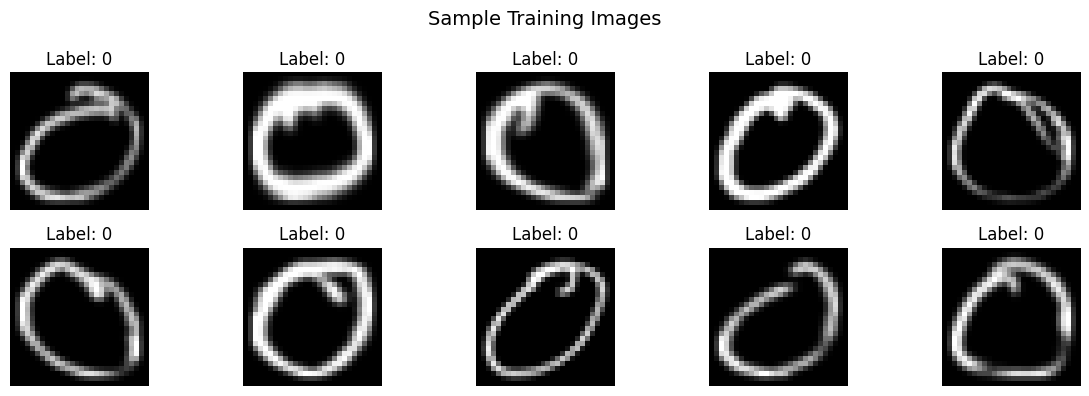

In [3]:
# Visualise sample training images
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.show()

#Task 2: Build the FCN Model
##Model Architecture
• Create a Sequential model using Keras.

• Add 3 hidden layers with the following number of neurons:

    – 1st hidden layer: 64 neurons

    – 2nd hidden layer: 128 neurons

    – 3rd hidden layer: 256 neurons

• Use sigmoid activation functions for all hidden layers.

• Add an output layer with 10 units with softmax (since Devnagari digits have 10 classes) and a
softmax activation function.

In [4]:
model = keras.Sequential(
    [
        keras.Input(shape=(IMG_HEIGHT * IMG_WIDTH,)),    # 784-dim input
        layers.Dense(64,  activation="sigmoid"),         # 1st hidden layer
        layers.Dense(128, activation="sigmoid"),         # 2nd hidden layer
        layers.Dense(256, activation="sigmoid"),         # 3rd hidden layer
        layers.Dense(NUM_CLASSES, activation="softmax"), # Output layer
    ],
    name="FCN_Devnagari"
)

model.summary()

Model: "FCN_Devnagari"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

#Task 3: Compile the Model

##Model Compilation

• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

In [5]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",   # Works with one-hot labels
    metrics=["accuracy"]
)
print("Model compiled successfully.")

Model compiled successfully.


#Task 4: Train the Model

##Model Training

• Use the model.fit() function to train the model. Set the batch size to 128 and the number of
epochs to 20.

• Use validation split (validation split=0.2) to monitor the model’s performance on validation
data.

• Optionally, use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model
and avoiding overfitting.

In [6]:
BATCH_SIZE = 128
EPOCHS     = 20

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
]

history = model.fit(
    x_train,
    y_train_ohe,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/20
101/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2946 - loss: 1.9801
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4861 - loss: 1.6172 - val_accuracy: 0.0000e+00 - val_loss: 7.5426
Epoch 2/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8091 - loss: 0.6313
Epoch 2: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8357 - loss: 0.5004 - val_accuracy: 0.0000e+00 - val_loss: 9.1656
Epoch 3/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9225 - loss: 0.2853
Epoch 3: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9276 - loss: 0.2628 - val_accuracy: 0.0000e+00 - val_loss: 9.6547
Epoch 4/20
 99/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9488 - loss: 0.1872
Epoch 4: val_accuracy did not improve from 0.00000
1

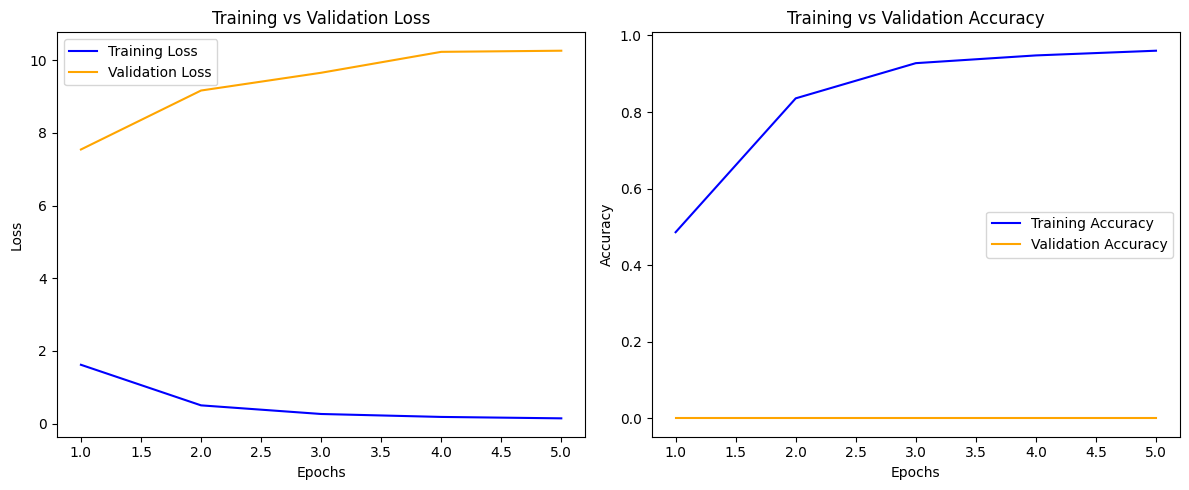

In [7]:
# Plot training curves
train_loss = history.history["loss"]
val_loss   = history.history["val_loss"]
train_acc  = history.history["accuracy"]
val_acc    = history.history["val_accuracy"]
epochs_ran = range(1, len(train_loss) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_ran, train_loss, label="Training Loss",   color="blue")
plt.plot(epochs_ran, val_loss,   label="Validation Loss", color="orange")
plt.xlabel("Epochs"); plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_ran, train_acc, label="Training Accuracy",   color="blue")
plt.plot(epochs_ran, val_acc,   label="Validation Accuracy", color="orange")
plt.xlabel("Epochs"); plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

#Task 5: Evaluate the Model


##Model Evaluation

• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test_ohe, verbose=2)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

94/94 - 1s - 7ms/step - accuracy: 0.6247 - loss: 2.1582

Test Loss     : 2.1582
Test Accuracy : 0.6247


#Task 6: Save and Load the Model

##Model Saving and Loading

• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set.

In [9]:
# Save the model
model.save("devnagari_fcn_model.h5")
print("Model saved → devnagari_fcn_model.h5")

# Load the model
loaded_model = tf.keras.models.load_model("devnagari_fcn_model.h5")
print("Model loaded successfully.")

# Re-evaluate loaded model
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test_ohe, verbose=2)
print(f"\nLoaded Model — Test Loss: {loaded_loss:.4f}  |  Test Accuracy: {loaded_acc:.4f}")

Model saved → devnagari_fcn_model.h5
Model loaded successfully.
94/94 - 1s - 7ms/step - accuracy: 0.6247 - loss: 2.1582

Loaded Model — Test Loss: 2.1582  |  Test Accuracy: 0.6247


#Task 7: Predictions

##Making Predictions

• Use model.predict() to make predictions on test images.

• Convert the model’s predicted probabilities to digit labels using np.argmax().

In [10]:
predictions      = loaded_model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = np.argmax(y_test_ohe,  axis=1)

print("--- Sample Predictions ---")
for i in range(5):
    print(f"  Image {i+1}: Predicted = {predicted_labels[i]},  True = {true_labels[i]}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
--- Sample Predictions ---
  Image 1: Predicted = 0,  True = 0
  Image 2: Predicted = 0,  True = 0
  Image 3: Predicted = 0,  True = 0
  Image 4: Predicted = 0,  True = 0
  Image 5: Predicted = 0,  True = 0


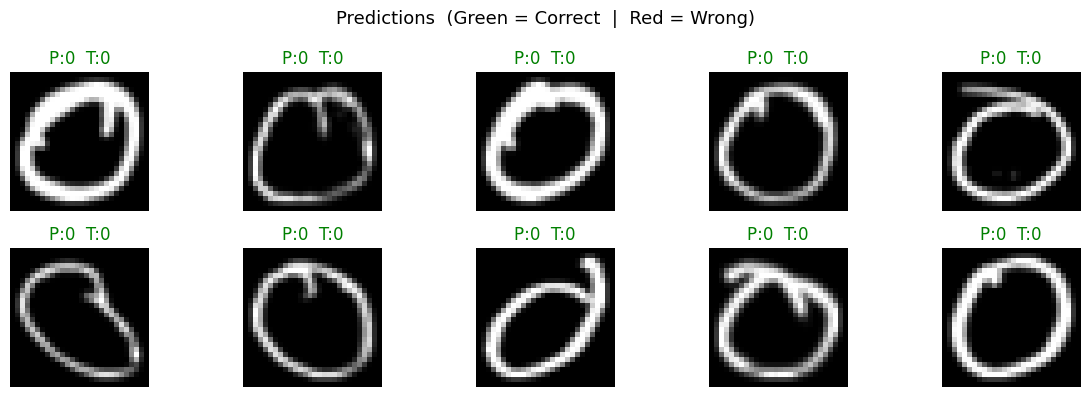

In [11]:
# Visualise predictions vs true labels
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    color = "green" if predicted_labels[i] == true_labels[i] else "red"
    plt.title(f"P:{predicted_labels[i]}  T:{true_labels[i]}", color=color)
    plt.axis("off")
plt.suptitle("Predictions  (Green = Correct  |  Red = Wrong)", fontsize=13)
plt.tight_layout()
plt.show()